# Compare amplitude and phase (sit/stand/walk)
This notebook loads three CSV files and compares amplitude and phase over time.
Update the file paths below if your files are in a different location.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is importable
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.amp_phase import process_file_with_metadata

In [2]:
# Update these paths if needed
sit_path = ROOT / 'data' / 'raw' / 'sit.csv'
stand_path = ROOT / 'data' / 'raw' / 'stand.csv'
walk_path = ROOT / 'data' / 'raw' / 'walk.csv'

# Fallbacks if the default files do not exist
fallbacks = {
    'sit': [ROOT / 'data' / 'raw' / 'sit1.csv', ROOT / 'data' / 'raw' / 'sit2.csv'],
    'stand': [ROOT / 'data' / 'raw' / 'stand1.csv', ROOT / 'data' / 'raw' / 'stand2.csv'],
    'walk': [ROOT / 'data' / 'raw' / 'walk1.csv', ROOT / 'data' / 'raw' / 'walk2.csv'],
}

def resolve_path(primary: Path, key: str) -> Path:
    if primary.exists():
        return primary
    for p in fallbacks.get(key, []):
        if p.exists():
            return p
    raise FileNotFoundError(f'No CSV found for {key}. Checked: {primary} and fallbacks.')

sit_path = resolve_path(sit_path, 'sit')
stand_path = resolve_path(stand_path, 'stand')
walk_path = resolve_path(walk_path, 'walk')

sit_path, stand_path, walk_path

(WindowsPath('C:/esp32/csi/data/raw/sit.csv'),
 WindowsPath('C:/esp32/csi/data/raw/stand.csv'),
 WindowsPath('C:/esp32/csi/data/raw/walk.csv'))

In [3]:
def load_amp_phase(path: Path, metadata_columns: int = 1):
    amp, phase, metadata = process_file_with_metadata(path, metadata_columns=metadata_columns, mode='auto')
    # Mean across subcarriers per frame
    amp_mean = np.mean(amp, axis=1)
    phase_mean = np.mean(phase, axis=1)
    return amp, phase, amp_mean, phase_mean

sit_amp, sit_phase, sit_amp_mean, sit_phase_mean = load_amp_phase(sit_path)
stand_amp, stand_phase, stand_amp_mean, stand_phase_mean = load_amp_phase(stand_path)
walk_amp, walk_phase, walk_amp_mean, walk_phase_mean = load_amp_phase(walk_path)

sit_amp.shape, stand_amp.shape, walk_amp.shape

((169873, 32), (163857, 32), (161844, 32))

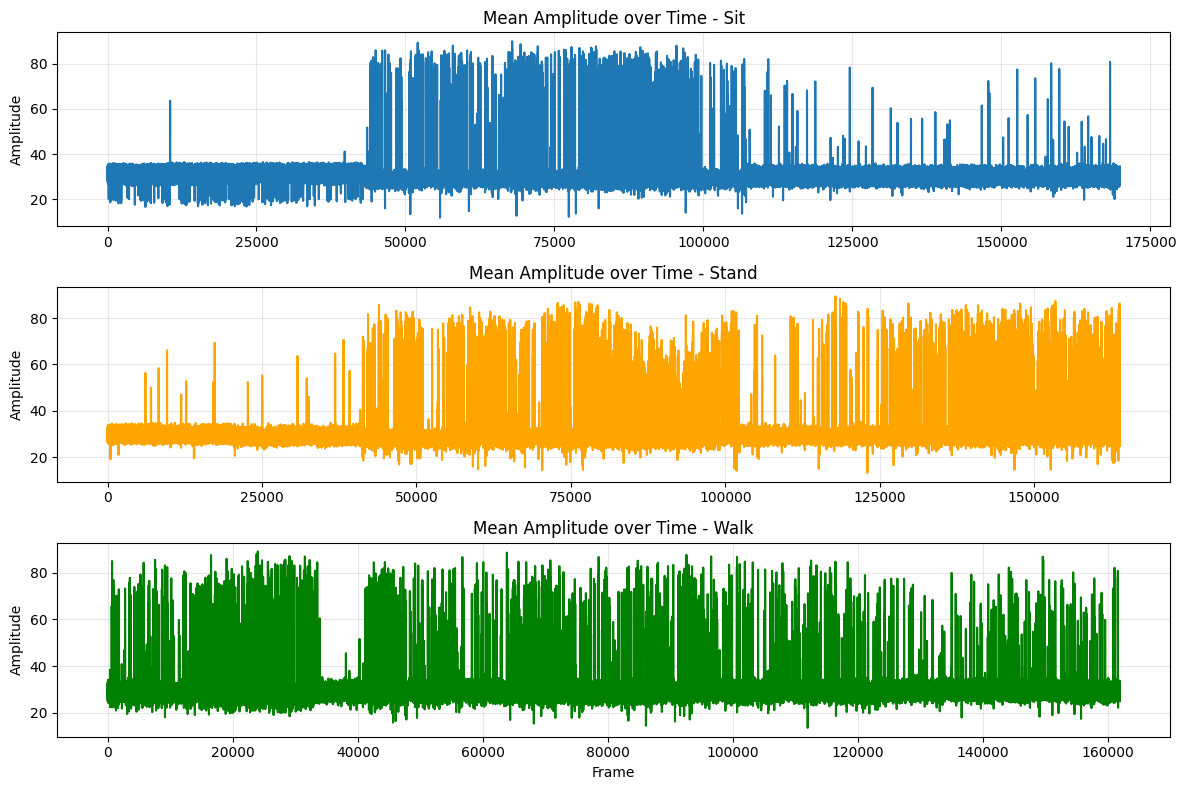

In [4]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(sit_amp_mean, label='Sit')
plt.title('Mean Amplitude over Time - Sit')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(stand_amp_mean, label='Stand', color='orange')
plt.title('Mean Amplitude over Time - Stand')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(walk_amp_mean, label='Walk', color='green')
plt.title('Mean Amplitude over Time - Walk')
plt.xlabel('Frame')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

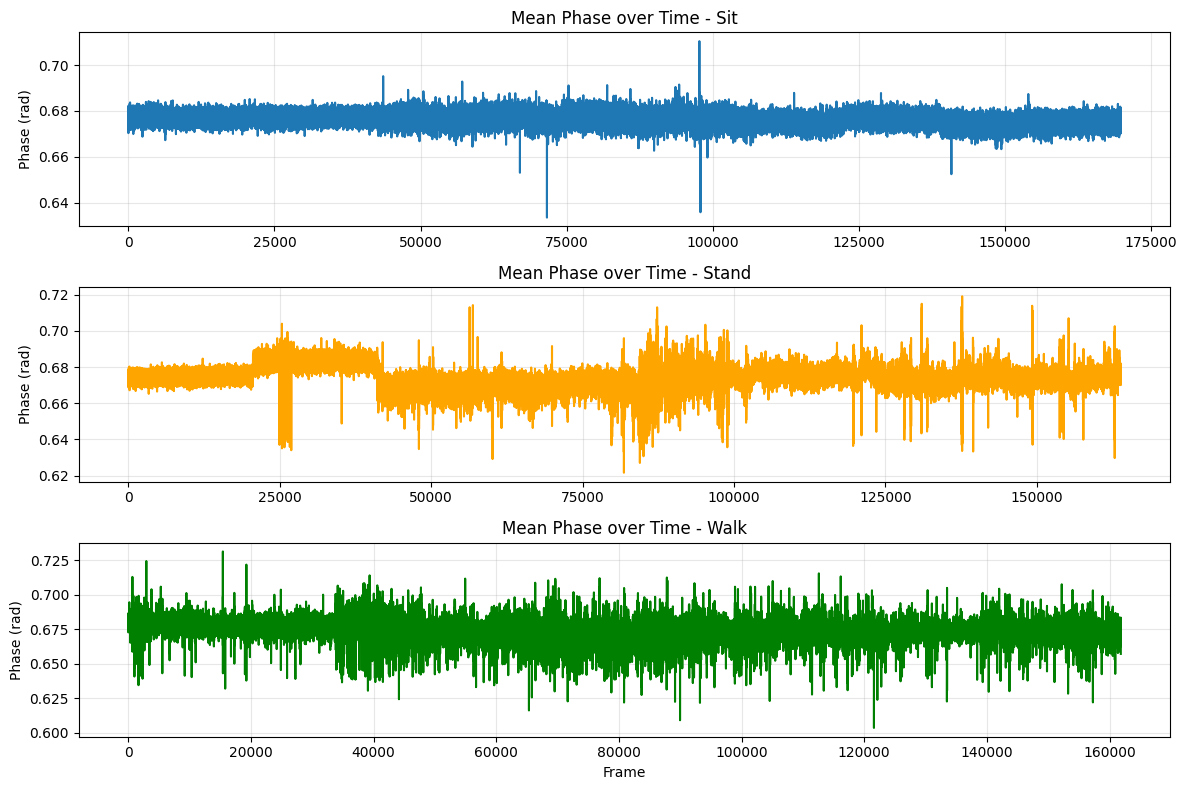

In [5]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(sit_phase_mean, label='Sit')
plt.title('Mean Phase over Time - Sit')
plt.ylabel('Phase (rad)')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(stand_phase_mean, label='Stand', color='orange')
plt.title('Mean Phase over Time - Stand')
plt.ylabel('Phase (rad)')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(walk_phase_mean, label='Walk', color='green')
plt.title('Mean Phase over Time - Walk')
plt.xlabel('Frame')
plt.ylabel('Phase (rad)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

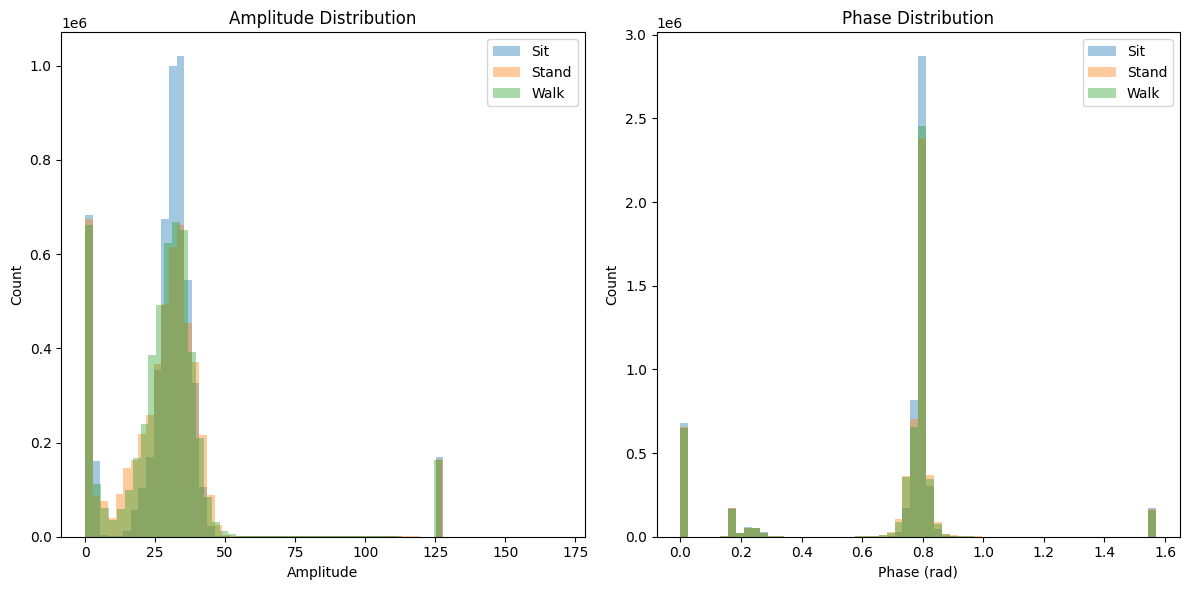

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(sit_amp.flatten(), bins=60, alpha=0.4, label='Sit')
plt.hist(stand_amp.flatten(), bins=60, alpha=0.4, label='Stand')
plt.hist(walk_amp.flatten(), bins=60, alpha=0.4, label='Walk')
plt.title('Amplitude Distribution')
plt.xlabel('Amplitude')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(sit_phase.flatten(), bins=60, alpha=0.4, label='Sit')
plt.hist(stand_phase.flatten(), bins=60, alpha=0.4, label='Stand')
plt.hist(walk_phase.flatten(), bins=60, alpha=0.4, label='Walk')
plt.title('Phase Distribution')
plt.xlabel('Phase (rad)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Normalize mean series for easier comparison (z-score per action)

def zscore(x: np.ndarray) -> np.ndarray:
    mu = np.mean(x)
    sigma = np.std(x) + 1e-8
    return (x - mu) / sigma

sit_amp_mean_z = zscore(sit_amp_mean)
stand_amp_mean_z = zscore(stand_amp_mean)
walk_amp_mean_z = zscore(walk_amp_mean)

sit_phase_mean_z = zscore(sit_phase_mean)
stand_phase_mean_z = zscore(stand_phase_mean)
walk_phase_mean_z = zscore(walk_phase_mean)

sit_amp_z = zscore(sit_amp.flatten())
stand_amp_z = zscore(stand_amp.flatten())
walk_amp_z = zscore(walk_amp.flatten())

sit_phase_z = zscore(sit_phase.flatten())
stand_phase_z = zscore(stand_phase.flatten())
walk_phase_z = zscore(walk_phase.flatten())

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(sit_amp_mean_z, label='Sit')
plt.title('Mean Amplitude (Z-score) over Time - Sit')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(stand_amp_mean_z, label='Stand', color='orange')
plt.title('Mean Amplitude (Z-score) over Time - Stand')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(walk_amp_mean_z, label='Walk', color='green')
plt.title('Mean Amplitude (Z-score) over Time - Walk')
plt.xlabel('Frame')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(sit_phase_mean_z, label='Sit')
plt.title('Mean Phase (Z-score) over Time - Sit')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(stand_phase_mean_z, label='Stand', color='orange')
plt.title('Mean Phase (Z-score) over Time - Stand')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(walk_phase_mean_z, label='Walk', color='green')
plt.title('Mean Phase (Z-score) over Time - Walk')
plt.xlabel('Frame')
plt.ylabel('Z')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(sit_amp_z, bins=60, alpha=0.4, label='Sit')
plt.hist(stand_amp_z, bins=60, alpha=0.4, label='Stand')
plt.hist(walk_amp_z, bins=60, alpha=0.4, label='Walk')
plt.title('Amplitude Distribution (Z-score)')
plt.xlabel('Z')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(sit_phase_z, bins=60, alpha=0.4, label='Sit')
plt.hist(stand_phase_z, bins=60, alpha=0.4, label='Stand')
plt.hist(walk_phase_z, bins=60, alpha=0.4, label='Walk')
plt.title('Phase Distribution (Z-score)')
plt.xlabel('Z')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()